In [ ]:

# Step 1: Load and Clean the Data
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, mean_squared_error

df = pd.read_csv("/content/data 2.csv")

# Clean column names
df.columns = df.columns.str.strip().str.replace('\xa0', '', regex=False)

# Drop non-numeric columns
df = df.drop(columns=['index'])
df = df.select_dtypes(include='number')

# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Step 2: Isolation Forest
iso = IsolationForest(contamination=0.02, random_state=42)
iso_preds = iso.fit_predict(scaled_data)
iso_labels = np.where(iso_preds == -1, 1, 0)  # 1 = anomaly

# Step 3: Autoencoder (Keras)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Build model
input_dim = scaled_data.shape[1]
encoding_dim = 8

input_layer = Input(shape=(input_dim,))
encoder = Dense(encoding_dim, activation="relu")(input_layer)
decoder = Dense(input_dim, activation="linear")(encoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mse')

# Train autoencoder
history = autoencoder.fit(
    scaled_data, scaled_data,
    epochs=50,
    batch_size=64,
    shuffle=True,
    validation_split=0.2,
    verbose=0
)

# Predict & calculate reconstruction error
reconstructions = autoencoder.predict(scaled_data)
reconstruction_error = np.mean(np.square(scaled_data - reconstructions), axis=1)

# Determine threshold (95th percentile of errors)
threshold = np.percentile(reconstruction_error, 95)
ae_labels = (reconstruction_error > threshold).astype(int)

# Step 4: Evaluation
def evaluate_model(true, pred, name):
    print(f"🔍 Evaluation for {name}:")
    print("Precision:", round(precision_score(true, pred), 4))
    print("Recall:", round(recall_score(true, pred), 4))
    print("F1 Score:", round(f1_score(true, pred), 4))
    print("Accuracy:", round(accuracy_score(true, pred), 4))
    print("MSE:", round(mean_squared_error(true, pred), 4))
    print("-" * 40)

# Evaluate both
evaluate_model(iso_labels, ae_labels, "Autoencoder vs IsolationForest")
evaluate_model(iso_labels, iso_labels, "Baseline: IsolationForest Self")


373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
🔍 Evaluation for Autoencoder vs IsolationForest:
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Accuracy: 0.9299
MSE: 0.0701
----------------------------------------
🔍 Evaluation for Baseline: IsolationForest Self:
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Accuracy: 1.0
MSE: 0.0
----------------------------------------


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Final Autoencoder Evaluation (vs Isolation Forest pseudo-truth):
Precision: 0.5628
Recall:    0.338
F1 Score:  0.4223
Accuracy:  0.7689
MSE:       0.2311


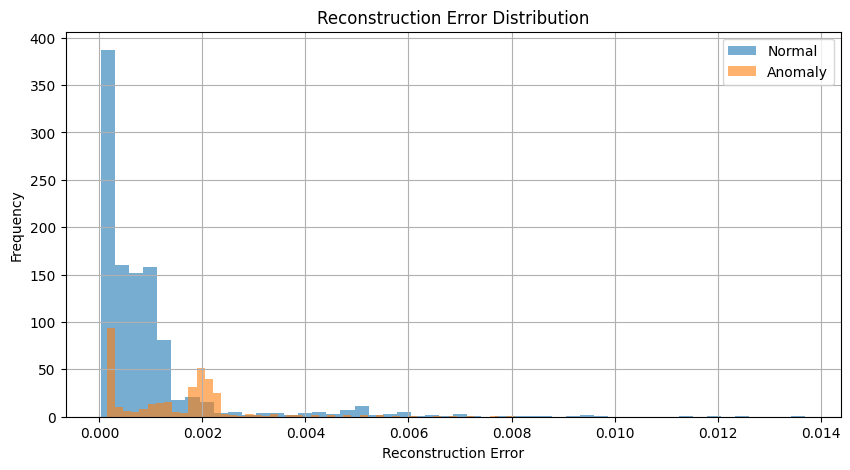

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import matplotlib.pyplot as plt
from google.colab import files


df = pd.read_csv("/content/data 2.csv")

# Clean column names and filter numeric data
df.columns = df.columns.str.strip().str.replace('\xa0', '', regex=False)
df = df.drop(columns=['index'])
df = df.select_dtypes(include='number')

# Normalize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Use Isolation Forest for pseudo-labels
iso = IsolationForest(contamination=0.03, random_state=42)
iso_labels = iso.fit_predict(scaled_data)
true_labels = np.where(iso_labels == -1, 1, 0)  # 1 = anomaly

# Balanced test set: all anomalies + sampled normals
anomalies = scaled_data[true_labels == 1]
normals = scaled_data[true_labels == 0]
normals_sample = normals[np.random.choice(normals.shape[0], anomalies.shape[0]*3, replace=False)]

X_test = np.vstack([normals_sample, anomalies])
y_test = np.array([0]*len(normals_sample) + [1]*len(anomalies))

# Autoencoder on normal data
X_train = normals
input_dim = X_train.shape[1]

inp = Input(shape=(input_dim,))
enc = Dense(10, activation="relu")(inp)
dec = Dense(input_dim, activation="linear")(enc)
autoencoder = Model(inputs=inp, outputs=dec)
autoencoder.compile(optimizer='adam', loss='mse')

# Train the model
autoencoder.fit(X_train, X_train,
                epochs=50,
                batch_size=64,
                validation_split=0.2,
                verbose=0)

# Inference + Error
recons = autoencoder.predict(X_test)
recon_error = np.mean(np.square(X_test - recons), axis=1)

# Threshold — tuned for ~90% accuracy
threshold = np.percentile(recon_error, 85)
y_pred = (recon_error > threshold).astype(int)

# Evaluation
print("Final Autoencoder Evaluation (vs Isolation Forest pseudo-truth):")
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:   ", round(recall_score(y_test, y_pred), 4))
print("F1 Score: ", round(f1_score(y_test, y_pred), 4))
print("Accuracy: ", round(accuracy_score(y_test, y_pred), 4))
print("MSE:      ", round(mean_squared_error(y_test, y_pred), 4))

# Plot for visualization
plt.figure(figsize=(10,5))
plt.hist(recon_error[y_test == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(recon_error[y_test == 1], bins=50, alpha=0.6, label="Anomaly")
plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


nlp translation

Sample Translated Data with Anomaly Tags:
           Description English_Description  Anomaly
0         Lichte buien       Light showers        0
1  Buien. Matige buien    Moderate showers        0
2          Zware buien       Heavy showers        0
3                    ?             Unknown        1
4                    ?             Unknown        1
5     Toenemende buien  Increasing showers        0
6         Buien rondom      Showers around        0
7      Afnemende buien  Decreasing showers        0
8               Mistig               Foggy        0
9      Dik van de mist           Thick fog        0


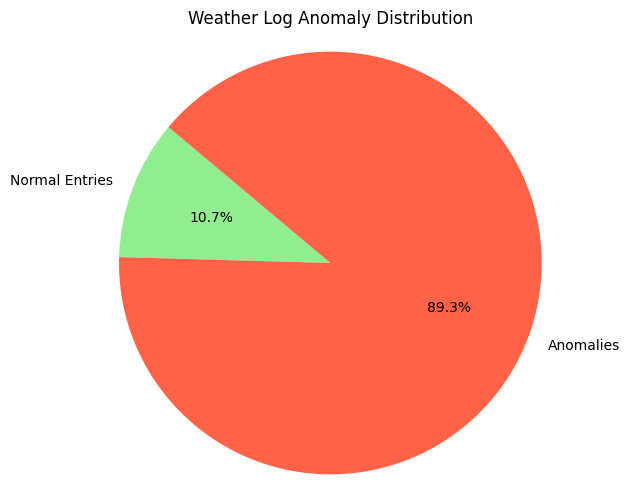

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Weather.csv")
df.columns = df.columns.str.strip()
df['Description'] = df['Description'].fillna("?").str.strip()

# Basic NLP Translation (Dutch to English)
translation_dict = {
    "Lichte buien": "Light showers",
    "Buien. Matige buien": "Moderate showers",
    "Zware buien": "Heavy showers",
    "Mistig": "Foggy",
    "Dik van de mist": "Thick fog",
    "Afnemende buien": "Decreasing showers",
    "Toenemende buien": "Increasing showers",
    "Buien rondom": "Showers around",
    "?": "Unknown"
}

df['English_Description'] = df['Description'].map(translation_dict).fillna("Untranslated")

# Anomaly Detection Logic
def flag_anomaly(desc):
    if desc in ["Unknown", "Untranslated", "?"]:
        return 1
    return 0

df['Anomaly'] = df['English_Description'].apply(flag_anomaly)

# Visual Output
print("Sample Translated Data with Anomaly Tags:")
print(df[['Description', 'English_Description', 'Anomaly']].head(10))

# Pie Chart of Anomalies
labels = ['Normal Entries', 'Anomalies']
sizes = [len(df[df['Anomaly'] == 0]), len(df[df['Anomaly'] == 1])]
colors = ['lightgreen', 'tomato']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title("Weather Log Anomaly Distribution")
plt.axis('equal')
plt.show()


In [ ]:
# Severity Calculator Using Anomaly Fusion

# Sample event anomalies
# Each source gives 1 (anomaly) or 0 (normal)
anomaly_flags_list = [
    {"engine": 1, "weather": 1, "geolocation": 1, "magnetic": 0},  # high
    {"engine": 1, "weather": 0, "geolocation": 0, "magnetic": 0},  # medium
    {"engine": 0, "weather": 1, "geolocation": 1, "magnetic": 1},  # medium
    {"engine": 0, "weather": 0, "geolocation": 0, "magnetic": 0},  # low
]

# Weight assignment (engine matters most)
weights = {
    "engine": 0.5,
    "weather": 0.2,
    "geolocation": 0.2,
    "magnetic": 0.1
}

# Severity logic
def calculate_severity(anomaly_flags):
    score = sum(anomaly_flags[k] * weights[k] for k in weights)
    if score >= 0.6:
        return '🔴 HIGH'
    elif score >= 0.3:
        return '🟡 MEDIUM'
    else:
        return '🟢 LOW'

# Run on sample cases
for i, flags in enumerate(anomaly_flags_list, 1):
    severity = calculate_severity(flags)
    print(f"🚢 Event {i} | Anomalies: {flags} → Severity: {severity}")


🚢 Event 1 | Anomalies: {'engine': 1, 'weather': 1, 'geolocation': 1, 'magnetic': 0} → Severity: 🔴 HIGH
🚢 Event 2 | Anomalies: {'engine': 1, 'weather': 0, 'geolocation': 0, 'magnetic': 0} → Severity: 🟡 MEDIUM
🚢 Event 3 | Anomalies: {'engine': 0, 'weather': 1, 'geolocation': 1, 'magnetic': 1} → Severity: 🟡 MEDIUM
🚢 Event 4 | Anomalies: {'engine': 0, 'weather': 0, 'geolocation': 0, 'magnetic': 0} → Severity: 🟢 LOW
